<a href="https://colab.research.google.com/github/SeyhanAkifov/AWSRetake/blob/main/code_reviewer_agent_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Code Reviewer Multi-Agent Workflow (LangGraph + LangChain)


This notebook implements a two-agent, language-agnostic **Code Reviewer** workflow that scans a
**whole real GitHub repository** — no single file path is configured — reviews and fixes every
matching file it finds **in parallel**, and ends each one in an actual **pull request**:

0. **Discovery** — the repository's file tree is listed via the GitHub REST API and filtered
   down to a reviewable, bounded set of source files (see `MAX_FILES_TO_REVIEW` in section 3).
   No LLM is involved in this step — it is plain.
1. **Reviewer Agent** — a senior-code-reviewer agent that examines each file's code for
   **security issues**, **clean-code issues**, and **architecture issues** using two tools, and
   always reaches a verdict: `APPROVE` or `REVISE`.
2. **Fixer Agent** — whenever the reviewer (or the human) is not satisfied, this agent rewrites
   the file to address the reviewer's findings and any direct human feedback. Capped at
   `MAX_REVISIONS_PER_FILE` revision cycles, after which the latest version is auto-approved
   instead of looping forever.
3. **Human-in-the-loop** — before anything is pushed to GitHub, the graph **pauses** (once per
   file) and asks a human to `approve`, `skip`, or send the file back with feedback (`revise`).
   Approving triggers the workflow's **critical action**: opening a real **pull request** with
   the fix for that file. This maps directly onto the assignment's own example of a critical
   action ("sending an email", "finalizing a report") — here it is "opening a pull request".

Every discovered file is reviewed by its own instance of the same per-file graph,
dispatched **in parallel** via LangGraph's `Send` primitive from an outer orchestrator graph.
Squad" example. `execute_workflow` discovers the files, runs the orchestrator, and
resolves however many files end up paused at their own human-review step at once.

The workflow is built as **two stacked stateful LangGraph graphs** with:
- A shared `TypedDict` state passed between agents within each file's review (also carrying
  LangGraph's message list for conversational memory), and a second, outer `TypedDict` state
  that fans work out to and collects results from every parallel file-review task.
- Two distinct custom tools used by the **Reviewer Agent** (`detect_language`,
  `run_code_review_checklist`) — both are plain Python functions.

- Plain GitHub REST API calls (via `requests`) to **list files**, **read** each file, and **open
  the pull request** — these are deterministic system actions, not left to an LLM's discretion,
  since opening a pull request is exactly the kind of irreversible action that must stay gated
  behind the human-in-the-loop step, not behind model judgement.
- An `InMemorySaver` checkpointer on the outer orchestrator graph, so a whole run (`thread_id`)
  -- every file being reviewed in parallel -- keeps its full history and can be paused/resumed.
- A real LangGraph `interrupt()` pause point for the human-in-the-loop step, resumed via
  `Command(resume=...)` keyed by each pending interrupt's `id` (there can be more than one at
  once, one per file still waiting on a human decision).

The LLM used for both agents is OpenAI **`gpt-5-nano`**.

### ⚠️ Setup required before running

This notebook targets a **real GitHub repository** (see section 3). Edit `GITHUB_REPO` and
`BASE_BRANCH` to point at a repo you control before running the notebook — there is no file
path to set; the workflow discovers files itself, up to `MAX_FILES_TO_REVIEW`. Reading a public
repo needs no token; **opening a real pull request needs a `GITHUB_TOKEN` Colab Secret with
write access to that repo.**

To keep the required automated test cases safe and repeatable (no pull-request spam every time
the notebook is graded/re-run), pull-request creation runs in **dry-run mode** during the test
cases — it logs exactly what it would have done instead of calling the GitHub API. Section 12
shows how to flip this off and actually open pull requests for real.

## 1. Install dependencies

Run once. Nothing else needs to be installed in the Colab runtime.

In [1]:
!pip install -q langchain langchain-openai langgraph requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 15.3 MB/s eta 0:00:00


## 2. Imports & shared helpers

In [2]:
import base64
import os
import re
import uuid
from pathlib import Path
from typing import Annotated, Dict, List, Literal, TypedDict
from unittest.mock import patch

import requests
from google.colab import userdata
from IPython.display import Image, display
from langchain.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain.tools import tool
from langchain_core.messages import BaseMessage
from langchain_core.runnables import Runnable, RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import ToolNode
from langgraph.types import Command, Send, interrupt
from pydantic import SecretStr


def print_conversation(conversation: List[BaseMessage]):
    for message in conversation:
        message.pretty_print()


def display_graph(runnable: Runnable, output_png: Path) -> None:
    with output_png.open(mode="wb") as file:
        file.write(runnable.get_graph(xray=True).draw_mermaid_png())

    display(Image(output_png, format="png"))


def explore_state_history(compiled_state_graph: CompiledStateGraph, config: RunnableConfig):
    state_history = list(compiled_state_graph.get_state_history(config))
    for snapshot in reversed(state_history):
        print(f"Step: {snapshot.metadata['step']}")
        print("Current state:")
        print(snapshot.values)
        print(f"Next: {snapshot.next}")
        print()

## 3. Target repository & API keys

**Edit the constants below** to point at a GitHub repository you control. There is no single
file path to configure -- the workflow discovers reviewable files itself (see section 6),
capped at `MAX_FILES_TO_REVIEW` so a big repo can't trigger an unbounded number of LLM calls or
pull requests.

- `OPENAI_API_KEY` — Colab Secret, required.
- `GITHUB_TOKEN` — Colab Secret, optional for reading a **public** repo, **required** to
  actually open a pull request (needs write access to `GITHUB_REPO`).


In [3]:
# --- Edit these before running --------------------------------------------------------------
GITHUB_REPO = "SeyhanAkifov/MoreMovies"          # repo
BASE_BRANCH = "master"                           # branch to scan / branch off of
MAX_FILES_TO_REVIEW = 3                          # upper bound on how many files one run touches
MAX_REVISIONS_PER_FILE = 2                       # safety cap: force approval after this many HUMAN revise cycles
QUALITY_THRESHOLD = 80                           # quality score (0-100) the auto-fix loop aims for
MAX_AUTO_FIX_ATTEMPTS = 2                        # safety cap: stop auto-fixing and ask the human after this many tries
# ----------------------------------------------------------------------------------------------

openai_api_key = userdata.get("OpenAIAPIKey")
github_token = userdata.get("GITHUBAPIKEY")

MODEL_NAME = "gpt-5-nano"

reviewer_llm_base = ChatOpenAI(model=MODEL_NAME, api_key=openai_api_key, reasoning_effort="low")
fixer_llm = ChatOpenAI(model=MODEL_NAME, api_key=openai_api_key, reasoning_effort="low")


##Langsmith config

In [4]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITHAPIKEY")
os.environ["LANGSMITH_PROJECT"] = "Code Reviewer Multi-Agent Workflow"
os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"

## 4. Shared state

One `TypedDict` is passed between every node in the graph. `messages` uses LangGraph's
`add_messages` reducer, which is what gives the workflow its conversational memory: every
node appends to the same running conversation instead of overwriting it.


In [5]:
class ReviewState(TypedDict):
    user_request: str
    messages: Annotated[List[BaseMessage], add_messages]
    target_file_path: str
    original_code: str
    language: str
    code: str
    review_feedback: str
    review_verdict: str
    quality_score: int
    auto_fix_count: int
    revision_count: int
    human_decision: str
    human_feedback: str
    pr_result: str


## 5. Tools

Two distinct custom tools, both plain Python (no external services, no per-language
compiler/runtime needed), used by the **Reviewer Agent** via `.bind_tools(...)`:

1. `detect_language` — guesses the programming language of a snippet from characteristic
   keywords/syntax.
2. `run_code_review_checklist` — a language-agnostic textual/regex scanner that reports
   **Security**, **Clean Code**, and **Architecture** findings, plus a deterministic
   **quality score** (100, minus a fixed penalty per finding -- 30 for Security, 10 for Clean
   Code, 15 for Architecture) that section 7b's automatic fix loop reads back.


In [6]:
@tool
def detect_language(code: str) -> str:
    """
    Detect the most likely programming language of a code snippet using keyword/syntax heuristics.

    Args:
        code: The source code snippet to analyze.
    """
    checks = {
        "csharp": [r"\busing\s+System", r"\bnamespace\s+\w+", r"\bpublic\s+class\b", r"\bConsole\.WriteLine\b"],
        "java": [r"\bpublic\s+static\s+void\s+main\b", r"\bSystem\.out\.println\b", r"\bimport\s+java\."],
        "javascript": [r"\bfunction\s+\w+\s*\(", r"=>", r"\bconst\s+\w+\s*=", r"\blet\s+\w+\s*=", r"console\.log\("],
        "python": [r"\bdef\s+\w+\(", r"\bimport\s+\w+", r"\bprint\(", r"\bself\b", r"\belif\b"],
    }
    scores = {
        lang: sum(1 for pattern in patterns if re.search(pattern, code))
        for lang, patterns in checks.items()
    }
    best_lang = max(scores, key=scores.get)
    return best_lang if scores[best_lang] > 0 else "unknown"


@tool
def run_code_review_checklist(code: str, language: str = "unknown") -> str:
    """
    Run a language-agnostic clean-code, security, and architecture checklist against a code
    snippet and return a structured findings report grouped by category.

    Args:
        code: The source code snippet to review.
        language: The programming language of the snippet (as reported by detect_language).
    """
    findings = {"Security": [], "Clean Code": [], "Architecture": []}
    lines = code.splitlines()

    # --- Security ---
    if re.search(r"(?i)(api[_-]?key|secret|password|passwd|token)\s*[:=]\s*[\"'][^\"']{3,}[\"']", code):
        findings["Security"].append("Possible hardcoded secret/credential found in the source code.")
    if re.search(r"(?i)(select|insert|update|delete)\b[^\n]*[\"']\s*\+", code) or re.search(
        r"(?i)\+\s*[\"']\s*(select|insert|update|delete)\b", code
    ):
        findings["Security"].append("Possible SQL injection risk: SQL query built via string concatenation.")
    if re.search(r"\beval\s*\(|\bexec\s*\(", code):
        findings["Security"].append("Use of eval()/exec() detected — can execute arbitrary code.")
    if re.search(r"catch\s*\([^)]*\)\s*\{\s*\}", code) or re.search(r"except[^:]*:\s*pass", code):
        findings["Security"].append("Empty catch/except block swallows errors silently.")

    # --- Clean Code ---
    long_lines = [i + 1 for i, l in enumerate(lines) if len(l) > 120]
    if long_lines:
        findings["Clean Code"].append(f"Line(s) too long (>120 chars): {long_lines}")
    if len(lines) > 60:
        findings["Clean Code"].append("Snippet is quite long; consider splitting responsibilities.")
    if re.search(r"\bTODO\b|\bFIXME\b", code):
        findings["Clean Code"].append("Leftover TODO/FIXME comment found.")
    if re.search(r"(?i)divide", code) and not re.search(
        r"(?i)(==\s*0|!=\s*0|dividebyzero|zerodivision)", code
    ):
        findings["Clean Code"].append(
            "A divide operation was found without a visible zero-check or divide-by-zero handling."
        )

    # --- Architecture ---
    if re.search(r"^\s*global\s+\w+", code, re.MULTILINE) or re.search(r"\bstatic\s+\w+\s+\w+\s*;", code):
        findings["Architecture"].append("Use of global/static mutable state detected — increases coupling.")

    # --- Quality score: deterministic, not judged by the LLM, so prepare_human_review_node ---
    # --- can reliably read it back to decide whether to auto-fix (see section 7b). ---
    penalty = (
        len(findings["Security"]) * 30
        + len(findings["Clean Code"]) * 10
        + len(findings["Architecture"]) * 15
    )
    quality_score = max(0, 100 - penalty)

    report = []
    for category, items in findings.items():
        if items:
            report.append(f"{category}:")
            report.extend(f"  - {item}" for item in items)
    if not report:
        report.append("No issues found.")
    report.append(f"Quality score: {quality_score}/100")
    return "\n".join(report)


tools = [detect_language, run_code_review_checklist]


## 6. GitHub integration (listing files, reading a file, opening a pull request)

These are deliberately **plain Python functions, not agent tools**: discovering/fetching files
needs no judgement, and opening a pull request is the workflow's critical, irreversible action,
so it must be triggered by the graph's control flow *after* human approval -- never left to an
LLM's own discretion.

`list_repo_files` lists the whole repo tree (`git/trees/{branch}?recursive=1`) and filters it
down to files with a known source-code extension, outside common vendor/build directories,
capped at `MAX_FILES_TO_REVIEW`.

`open_pull_request_with_fix` respects `DRY_RUN_PULL_REQUESTS`: while `True` (the default, and
what the 6 test cases in section 11 use), no GitHub API call is made -- it just returns a
description of what would have happened.


In [7]:
GITHUB_API_URL = "https://api.github.com"

EXTENSION_LANGUAGE_MAP = {
    ".py": "python", ".cs": "csharp", ".js": "javascript", ".ts": "typescript",
    ".java": "java", ".rb": "ruby", ".go": "go", ".cpp": "cpp", ".c": "c",
}
EXCLUDED_PATH_SUBSTRINGS = ("node_modules/", "vendor/", "dist/", "build/", ".git/", "/generated/")


def _guess_language_from_extension(path: str) -> str:
    return EXTENSION_LANGUAGE_MAP.get(Path(path).suffix.lower(), "text")


def _is_reviewable_path(path: str) -> bool:
    if Path(path).suffix.lower() not in EXTENSION_LANGUAGE_MAP:
        return False
    return not any(excluded in path for excluded in EXCLUDED_PATH_SUBSTRINGS)


def _github_headers() -> dict:
    headers = {"Accept": "application/vnd.github+json"}
    if github_token:
        headers["Authorization"] = f"Bearer {github_token}"
    return headers


def list_repo_files(file_filter=_is_reviewable_path, max_files=MAX_FILES_TO_REVIEW) -> List[str]:
    """List up to `max_files` reviewable file paths in GITHUB_REPO at BASE_BRANCH."""
    url = f"{GITHUB_API_URL}/repos/{GITHUB_REPO}/git/trees/{BASE_BRANCH}"
    response = requests.get(url, headers=_github_headers(), params={"recursive": "1"})
    response.raise_for_status()
    tree = response.json().get("tree", [])
    paths = [item["path"] for item in tree if item.get("type") == "blob"]
    if file_filter is not None:
        paths = [p for p in paths if file_filter(p)]
    if max_files is not None:
        paths = paths[:max_files]
    return paths


def fetch_file_content(path: str) -> str:
    """Fetch `path` from GITHUB_REPO at BASE_BRANCH via the GitHub REST API."""
    url = f"{GITHUB_API_URL}/repos/{GITHUB_REPO}/contents/{path}"
    response = requests.get(url, headers=_github_headers(), params={"ref": BASE_BRANCH})
    response.raise_for_status()
    payload = response.json()
    return base64.b64decode(payload["content"]).decode("utf-8")


DRY_RUN_PULL_REQUESTS = True  # Test cases in section 10 keep this True. See section 11 to go live.


def open_pull_request_with_fix(path: str, new_content: str, commit_message: str, pr_title: str, pr_body: str) -> str:
    """
    Open a pull request on GITHUB_REPO with `new_content` written to `path`, on a new branch
    created off BASE_BRANCH. This is the workflow's critical action -- only ever called from
    open_pr_node, after the human has approved (see the graph in section 8).
    """
    if DRY_RUN_PULL_REQUESTS:
        preview = new_content if len(new_content) <= 800 else new_content[:800] + "\n... (truncated)"
        return (
            "[DRY RUN -- no GitHub API call was made]\n"
            f"Would branch off '{BASE_BRANCH}' in {GITHUB_REPO}, commit to '{path}':\n"
            f"  commit message: {commit_message}\n"
            f"Would open a pull request:\n"
            f"  title: {pr_title}\n"
            f"  body: {pr_body}\n\n"
            f"Updated file preview:\n{preview}"
        )

    headers = _github_headers()

    base_ref_resp = requests.get(f"{GITHUB_API_URL}/repos/{GITHUB_REPO}/git/ref/heads/{BASE_BRANCH}", headers=headers)
    base_ref_resp.raise_for_status()
    base_sha = base_ref_resp.json()["object"]["sha"]

    new_branch = f"code-review-fix-{uuid.uuid4().hex[:8]}"
    create_branch_resp = requests.post(
        f"{GITHUB_API_URL}/repos/{GITHUB_REPO}/git/refs",
        headers=headers,
        json={"ref": f"refs/heads/{new_branch}", "sha": base_sha},
    )
    create_branch_resp.raise_for_status()

    current_file_resp = requests.get(
        f"{GITHUB_API_URL}/repos/{GITHUB_REPO}/contents/{path}",
        headers=headers,
        params={"ref": BASE_BRANCH},
    )
    current_file_resp.raise_for_status()
    current_sha = current_file_resp.json()["sha"]

    update_resp = requests.put(
        f"{GITHUB_API_URL}/repos/{GITHUB_REPO}/contents/{path}",
        headers=headers,
        json={
            "message": commit_message,
            "content": base64.b64encode(new_content.encode("utf-8")).decode("ascii"),
            "sha": current_sha,
            "branch": new_branch,
        },
    )
    update_resp.raise_for_status()

    pr_resp = requests.post(
        f"{GITHUB_API_URL}/repos/{GITHUB_REPO}/pulls",
        headers=headers,
        json={"title": pr_title, "head": new_branch, "base": BASE_BRANCH, "body": pr_body},
    )
    pr_resp.raise_for_status()
    return pr_resp.json()["html_url"]


## 7. Agents

### Reviewer Agent
Bound to the two tools from section 5 via `.bind_tools(...)`. It always calls both tools before
giving its verdict, then ends its answer with a `VERDICT: APPROVE` or `VERDICT: REVISE` line.

### Fixer Agent
Rewrites the file to address the reviewer's findings and (once a human is involved) any direct
human feedback. It runs in two different situations, both routed by the functions below:
- **Automatically**, before any human is asked anything at all, whenever the quality score from
  `run_code_review_checklist` is below `QUALITY_THRESHOLD` -- `route_after_prepare_review`
  loops Reviewer ⟷ Fixer on their own, capped at `MAX_AUTO_FIX_ATTEMPTS` attempts.
- **On human request** ("revise"), same as before, capped separately at
  `MAX_REVISIONS_PER_FILE`.


In [8]:
REVIEWER_SYSTEM_PROMPT = """You are a senior code reviewer specializing in clean code, security, and software architecture, across ANY programming language (Python, C#, JavaScript, Java, etc.).

You will be given a code snippet to review. You have two tools available:
1. detect_language - detect the programming language of the snippet.
2. run_code_review_checklist - run a structured clean-code/security/architecture checklist against the snippet.

Always call both tools before giving your verdict. Base your review on their output plus your own judgement.

Structure your final answer exactly like this:
Security: <findings or "None">
Clean Code: <findings or "None">
Architecture: <findings or "None">
Summary: <one or two sentences>
VERDICT: APPROVE

or

VERDICT: REVISE

Use REVISE if there is at least one security issue, or a serious bug/robustness problem. Otherwise use APPROVE. The VERDICT line must be the very last line of your answer, in exactly that format."""

reviewer_llm = reviewer_llm_base.bind_tools(tools)


def reviewer_node(state: ReviewState):
    response = reviewer_llm.invoke([SystemMessage(REVIEWER_SYSTEM_PROMPT)] + state["messages"])
    return {"messages": [response]}


def route_after_review(state: ReviewState) -> Literal["tools", "prepare_human_review"]:
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return "prepare_human_review"


VERDICT_PATTERN = re.compile(r"VERDICT:\s*(APPROVE|REVISE)", re.IGNORECASE)
QUALITY_SCORE_PATTERN = re.compile(r"Quality score:\s*(\d+)/100")


def prepare_human_review_node(state: ReviewState):
    last_message = state["messages"][-1]
    content = last_message.content if isinstance(last_message.content, str) else str(last_message.content)
    match = VERDICT_PATTERN.search(content)
    verdict = match.group(1).upper() if match else "REVISE"

    # Read the score back from the tool's own output (deterministic), not from the model's
    # free-text summary -- it isn't asked to repeat the score, and might not.
    quality_score = 100
    for message in reversed(state["messages"]):
        if isinstance(message, ToolMessage) and message.name == "run_code_review_checklist":
            score_match = QUALITY_SCORE_PATTERN.search(message.content)
            if score_match:
                quality_score = int(score_match.group(1))
            break

    return {"review_feedback": content, "review_verdict": verdict, "quality_score": quality_score}


def route_after_prepare_review(state: ReviewState) -> Literal["fixer", "human_review"]:
    quality_score = state.get("quality_score", 100)
    auto_fix_count = state.get("auto_fix_count", 0)
    if quality_score < QUALITY_THRESHOLD and auto_fix_count < MAX_AUTO_FIX_ATTEMPTS:
        print(
            f"[{state['target_file_path']}] Quality score {quality_score}/100 is below "
            f"QUALITY_THRESHOLD ({QUALITY_THRESHOLD}); running an automatic fix attempt "
            f"({auto_fix_count + 1}/{MAX_AUTO_FIX_ATTEMPTS}) before asking a human."
        )
        return "fixer"
    return "human_review"


In [9]:
FIXER_SYSTEM_PROMPT = """You are a senior software engineer acting as a code Fixer.
You are given an existing file's code, a code reviewer's findings, and (optionally) direct human feedback. Your job is to rewrite the file to address that feedback.

Rules:
- Return ONLY the full corrected source code for the file. No explanations, no markdown fences.
- Preserve the existing style, structure, and language of the file wherever the feedback does not require a change.
- Address every point raised in the reviewer feedback and the human feedback."""


def _strip_code_fences(text: str) -> str:
    text = text.strip()
    if text.startswith("```"):
        lines = text.splitlines()
        lines = lines[1:]
        if lines and lines[-1].strip().startswith("```"):
            lines = lines[:-1]
        return "\n".join(lines).strip()
    return text


def fixer_node(state: ReviewState):
    prompt = (
        f"Original request/focus: {state['user_request']}\n\n"
        f"Current code:\n{state['code']}\n\n"
        f"Reviewer feedback:\n{state.get('review_feedback', '')}\n\n"
        f"Human feedback:\n{state.get('human_feedback', '')}\n\n"
        "Rewrite the file to address this feedback. Return ONLY the updated code."
    )
    response = fixer_llm.invoke([SystemMessage(FIXER_SYSTEM_PROMPT), HumanMessage(prompt)])
    code_text = _strip_code_fences(response.content)

    handoff_message = HumanMessage(
        content=(
            f"Please review this revised {state['language']} version of `{state['target_file_path']}`:\n\n"
            f"```{state['language']}\n{code_text}\n```"
        )
    )
    result = {"code": code_text, "messages": [handoff_message]}

    # Only bump auto_fix_count on an automatic pass (before any human decision exists yet).
    # A human-directed revise already bumps revision_count in human_review_node instead.
    if state.get("human_decision") != "revise":
        result["auto_fix_count"] = state.get("auto_fix_count", 0) + 1

    return result


### Fetching a file & the human-in-the-loop node

`fetch_code_node` is the graph's entry point: it deterministically pulls the current content of
`state["target_file_path"]` from GitHub (no LLM involved -- there is no judgement call to make
here). Each file reviewed by `execute_workflow` runs this same graph with a different
`target_file_path` in its initial state (see section 9).

`human_review_node` calls LangGraph's `interrupt(...)` — this is the point where the graph
actually **pauses**. Whatever dict is passed to `interrupt(...)` is handed back to the caller;
whatever value is later passed to `Command(resume=...)` is what `interrupt(...)` returns when
the graph resumes. The human has three options:
- `approve` → the critical action runs: a pull request is opened (`open_pr`).
- `skip` → the file is left untouched, no fix, no pull request (`skip`).
- `revise` → the findings and feedback go back to the **Fixer** for another attempt -- capped
  at `MAX_REVISIONS_PER_FILE`; beyond that, the node forces an `approve` of the latest version
  instead of looping forever.

The node itself only returns a plain state update; a separate `route_after_human_review`
function (used with `add_conditional_edges`) decides which of the three branches to take.


In [10]:
def fetch_code_node(state: ReviewState):
    path = state["target_file_path"]
    code_text = fetch_file_content(path)
    language = _guess_language_from_extension(path)

    handoff_message = HumanMessage(
        content=(
            f"Please review the following code from `{path}` in `{GITHUB_REPO}` "
            f"(branch `{BASE_BRANCH}`).\n\n"
            f"Reviewer focus / user request: {state['user_request']}\n\n"
            f"```{language}\n{code_text}\n```"
        )
    )
    return {
        "code": code_text,
        "original_code": code_text,
        "language": language,
        "messages": [handoff_message],
    }


def human_review_node(state: ReviewState):
    decision_payload = interrupt(
        {
            "question": (
                "Type 'approve' to open a pull request with this code, 'skip' to leave this "
                "file untouched, or 'revise' to send it back with feedback."
            ),
            "target_file_path": state["target_file_path"],
            "language": state["language"],
            "code": state["code"],
            "review_verdict": state["review_verdict"],
            "quality_score": state.get("quality_score", 100),
            "review": state["review_feedback"],
        }
    )

    decision = decision_payload["decision"].strip().lower()
    feedback = decision_payload.get("feedback", "")
    revision_count = state.get("revision_count", 0)

    if decision == "revise" and revision_count >= MAX_REVISIONS_PER_FILE:
        print(
            f"Reached MAX_REVISIONS_PER_FILE ({MAX_REVISIONS_PER_FILE}) for "
            f"'{state['target_file_path']}'; forcing approval of the latest version."
        )
        decision = "approve"

    result = {"human_decision": decision, "human_feedback": feedback}
    if decision == "revise":
        result["revision_count"] = revision_count + 1

    return result


def route_after_human_review(state: ReviewState) -> Literal["fixer", "open_pr", "skip"]:
    decision = state.get("human_decision")
    if decision == "approve":
        return "open_pr"
    if decision == "skip":
        return "skip"
    return "fixer"


def open_pr_node(state: ReviewState):
    path = state["target_file_path"]
    if state["code"] == state["original_code"]:
        return {
            "pr_result": (
                f"No changes were necessary for '{path}' -- the reviewer/human approved it "
                "as-is. No pull request was opened."
            )
        }

    commit_message = f"Apply automated code review fixes to {path}"
    pr_title = f"Code review fix: {path}"
    pr_body = (
        f"Automated fix proposed by the Code Reviewer multi-agent workflow.\n\n"
        f"User request/focus: {state['user_request']}\n\n"
        f"Final quality score: {state.get('quality_score', 'N/A')}/100 "
        f"(automatic fix attempts: {state.get('auto_fix_count', 0)}/{MAX_AUTO_FIX_ATTEMPTS})\n\n"
        f"Reviewer findings:\n{state.get('review_feedback', '')}\n\n"
        f"Human feedback incorporated:\n{state.get('human_feedback', '')}"
    )
    pr_result = open_pull_request_with_fix(path, state["code"], commit_message, pr_title, pr_body)
    return {"pr_result": pr_result}


def skip_node(state: ReviewState):
    return {
        "pr_result": (
            f"Skipped by human reviewer for '{state['target_file_path']}' -- no changes were "
            "made and no pull request was opened."
        )
    }


## 8. Build the per-file review graph

`fetch_code → reviewer → prepare_human_review` now forks: `route_after_prepare_review` sends
low-quality-score files back to `fixer` automatically (⟲, no human involved yet) and only lets
`human_review` see a file once its score clears `QUALITY_THRESHOLD` or `MAX_AUTO_FIX_ATTEMPTS`
is used up. From there it's the same human-review → open PR / skip / (human-driven) fixer graph
as before.

The graph is compiled **without** its own checkpointer: when it is embedded as a node inside the
parallel orchestrator graph in section 8b, the orchestrator's checkpointer is what actually
persists state and handles the interrupt/resume for it.


In [11]:
tool_node = ToolNode(tools)

file_review_builder = StateGraph(ReviewState)
file_review_builder.add_node("fetch_code", fetch_code_node)
file_review_builder.add_node("reviewer", reviewer_node)
file_review_builder.add_node("tools", tool_node)
file_review_builder.add_node("prepare_human_review", prepare_human_review_node)
file_review_builder.add_node("human_review", human_review_node)
file_review_builder.add_node("fixer", fixer_node)
file_review_builder.add_node("open_pr", open_pr_node)
file_review_builder.add_node("skip", skip_node)

file_review_builder.add_edge(START, "fetch_code")
file_review_builder.add_edge("fetch_code", "reviewer")
file_review_builder.add_conditional_edges("reviewer", route_after_review, ["tools", "prepare_human_review"])
file_review_builder.add_edge("tools", "reviewer")
file_review_builder.add_conditional_edges("prepare_human_review", route_after_prepare_review, ["fixer", "human_review"])
file_review_builder.add_conditional_edges("human_review", route_after_human_review, ["fixer", "open_pr", "skip"])
file_review_builder.add_edge("fixer", "reviewer")
file_review_builder.add_edge("open_pr", END)
file_review_builder.add_edge("skip", END)

file_review_graph = file_review_builder.compile()


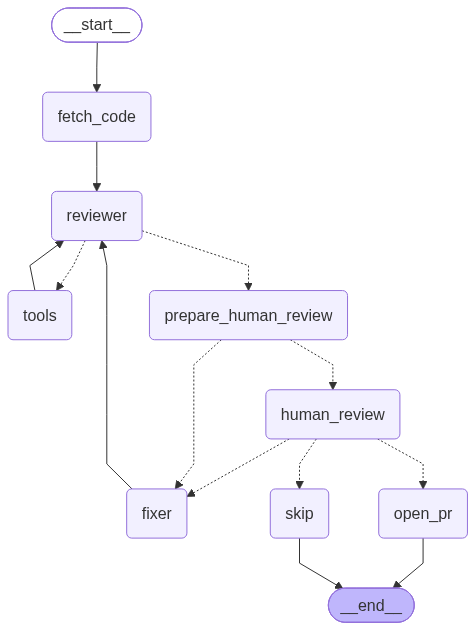

In [12]:
display_graph(file_review_graph, Path("/content/file_review_graph.png"))


## 8b. Build the orchestrator graph (parallel fan-out via `Send`)

`execute_workflow` needs to review *multiple* files per run. Instead of a plain Python loop,
this uses LangGraph's `Send` primitive to dispatch every discovered file as its own parallel
task
All dispatched files run their
`file_review_graph` concurrently within the same step, and if several of them hit their own
`human_review` interrupt (section 9) collects and answers
all of them together, keyed by each interrupt's `id`.

- `orchestrate` figures out which files still need a result.
- `delegate_reviews` turns each pending file into a `Send("review_one_file", {...})` -- a
  fan-out of parallel tasks -- or returns `END` once nothing is pending.
- `review_one_file` is the `file_review_graph` piped into `package_file_result`, which adapts
  its output into the orchestrator's own state shape.
- `results` merges every task's single-file output via `merge_dicts`, the same reducer pattern
  used in the course's marketing-squad example.

This is also why `file_review_graph` (section 8) has no checkpointer of its own: only
`orchestrator_graph` is compiled with one, and that's what actually persists state/interrupts
for every parallel branch.


In [13]:
def merge_dicts(a: Dict, b: Dict) -> Dict:
    return {**a, **b}


class OrchestratorState(TypedDict):
    user_request: str
    file_paths: List[str]
    pending_work: List[str]
    results: Annotated[Dict[str, dict], merge_dicts]


def orchestrate(state: OrchestratorState):
    file_paths = state.get("file_paths", [])
    results = state.get("results", {})
    pending_work = [path for path in file_paths if path not in results]
    return {"pending_work": pending_work}


def delegate_reviews(state: OrchestratorState):
    pending_work = state.get("pending_work", [])
    if not pending_work:
        return END
    return [
        Send(
            "review_one_file",
            {
                "user_request": state["user_request"],
                "target_file_path": path,
                "messages": [],
                "revision_count": 0,
            },
        )
        for path in pending_work
    ]


def package_file_result(state: ReviewState):
    return {"results": {state["target_file_path"]: dict(state)}}


orchestrator_builder = StateGraph(OrchestratorState)
orchestrator_builder.add_node("orchestrator", orchestrate)
orchestrator_builder.add_node("review_one_file", file_review_graph | package_file_result)

orchestrator_builder.add_edge(START, "orchestrator")
orchestrator_builder.add_conditional_edges("orchestrator", delegate_reviews, ["review_one_file", END])
orchestrator_builder.add_edge("review_one_file", "orchestrator")

orchestrator_graph = orchestrator_builder.compile(checkpointer=InMemorySaver())


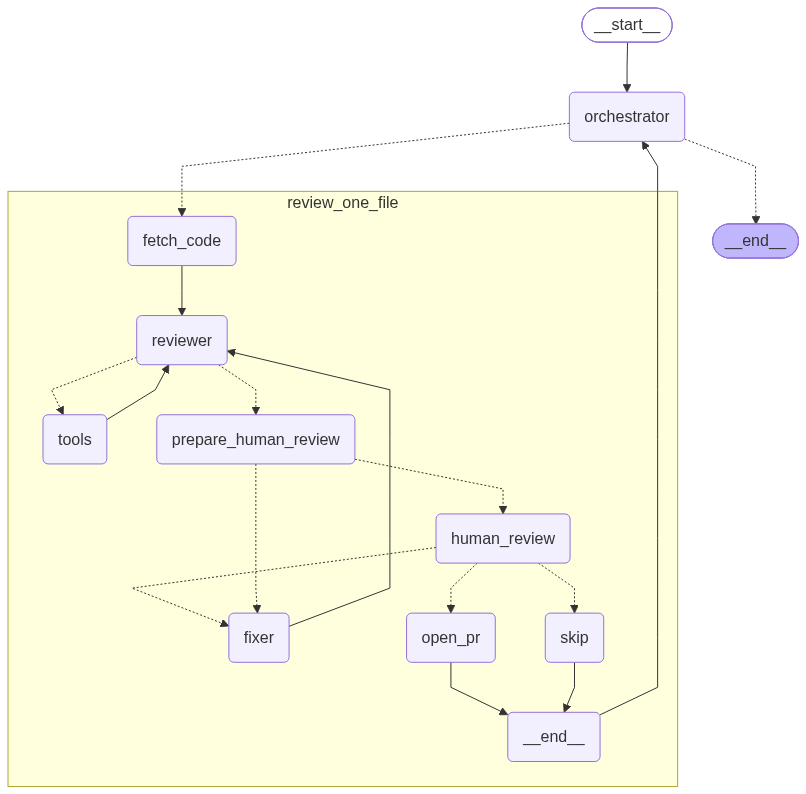

In [14]:
display_graph(orchestrator_graph, Path("/content/orchestrator_graph.png"))


## 9. Core function: `execute_workflow`

`execute_workflow(user_request)` is the single entry point -- it
still takes just the one string. Internally it:

1. Discovers up to `MAX_FILES_TO_REVIEW` reviewable files in `GITHUB_REPO` (section 6).
2. Invokes `orchestrator_graph` once, which fans out a parallel `review_one_file` task per file
   (section 8b) under one shared `thread_id`.
3. While `"__interrupt__"` is present in the result, it can contain **one entry per file**
   currently paused at its own `human_review` step (they can pause at different times, but a
   round can easily include several at once). For every pending interrupt it prints the file,
   code, and review, asks for human input (`approve` / `skip` / `revise` + optional feedback),
   and builds one `Command(resume=...)` dict keyed by each interrupt's `id` so every answer
   routes back to the right file. Repeats until every file has a result.
4. Prints a one-line summary per file and returns a `{file_path: final_state}` dict.

`LAST_RUN_CONFIG` is kept around purely so section 11 can peek at this run's checkpoint history
afterwards.


In [15]:
LAST_RUN_CONFIG = None


def execute_workflow(user_request: str) -> dict:
    global LAST_RUN_CONFIG

    file_paths = list_repo_files()
    if not file_paths:
        print(
            "No reviewable files were found. Check GITHUB_REPO/BASE_BRANCH (section 3), or "
            "the MAX_FILES_TO_REVIEW / _is_reviewable_path filters (section 6)."
        )
        return {}

    print(f"Discovered {len(file_paths)} file(s) to review in parallel: {file_paths}")

    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}
    LAST_RUN_CONFIG = config

    state = orchestrator_graph.invoke(
        {"user_request": user_request, "file_paths": file_paths, "results": {}},
        config=config,
    )

    while "__interrupt__" in state:
        pending_interrupts = state["__interrupt__"]
        resume_payload = {}

        for pending in pending_interrupts:
            payload = pending.value

            print("\n--- HUMAN REVIEW REQUIRED ---")
            print(f"File: {payload['target_file_path']}")
            print(f"Language: {payload['language']}")
            print(f"Code:\n{payload['code']}\n")
            print(f"Reviewer verdict: {payload['review_verdict']} (quality score: {payload['quality_score']}/100)")
            print(f"Reviewer feedback:\n{payload['review']}\n")

            prompt = f"[{payload['target_file_path']}] {payload['question']} [approve/skip/revise]: "
            decision = input(prompt).strip().lower()
            entry = {"decision": decision}
            if decision == "revise":
                entry["feedback"] = input("Enter your feedback for revision: ").strip()
            resume_payload[pending.id] = entry

        state = orchestrator_graph.invoke(Command(resume=resume_payload), config=config)

    print("\n--- REPOSITORY REVIEW COMPLETE ---")
    for path, result in state["results"].items():
        print(f"- {path}: {result['pr_result'].splitlines()[0]}")
    return state["results"]


## 10. Test cases

Six different `user_request` strings (one more than the required minimum of five), each asking
the Reviewer to focus on a different aspect (security, clean code, robustness, secrets,
architecture) while scanning the same configured repository in parallel. `builtins.input` is
mocked with `unittest.mock.patch` to simulate the human's answers -- this is only there to make
the test cases run unattended in this notebook; `execute_workflow` itself still only takes the
single `user_request` string, and `input()` will prompt a real user if you call it
interactively without mocking. `DRY_RUN_PULL_REQUESTS` stays `True` here, so no real pull
request is opened by these test cases.

Because the exact number of files (and therefore interrupts, possibly several at once per
round) depends on the repo you configured, the test cases use small **callables** as
`side_effect` instead of a fixed list -- they never run out of scripted answers no matter how
many files or rounds occur:
- `always_approve` answers "approve" to every interrupt, for every file.
- `revise_once_then_approve(feedback)` answers "revise" (plus feedback) the first time it's
  asked, then "approve" for every interrupt after that -- exactly one revision cycle,
  regardless of how many files were discovered or dispatched in parallel.
- `skip_once_then_approve()` answers "skip" the first time, then "approve" after that --
  demonstrates the skip path added for exactly this purpose.


In [16]:
def run_test_case(title: str, user_request: str, simulated_inputs) -> dict:
    print("=" * 88)
    print(f"TEST CASE: {title}")
    print(f"User request: {user_request}")
    print("=" * 88)
    with patch("builtins.input", side_effect=simulated_inputs):
        results = execute_workflow(user_request)
    for path, result in results.items():
        print()
        print_conversation(result["messages"])
    print()
    return results


def always_approve(prompt: str) -> str:
    return "approve"


def revise_once_then_approve(feedback: str):
    calls = {"n": 0}

    def _input(prompt: str) -> str:
        calls["n"] += 1
        if calls["n"] == 1:
            return "revise"
        if calls["n"] == 2:
            return feedback
        return "approve"

    return _input


def skip_once_then_approve():
    calls = {"n": 0}

    def _input(prompt: str) -> str:
        calls["n"] += 1
        return "skip" if calls["n"] == 1 else "approve"

    return _input


In [17]:
# 1) General pass -> human approves every file immediately.
result_1 = run_test_case(
    title="General review (expect: approve immediately)",
    user_request="Please review this file for any obvious bugs and fix them if you find any.",
    simulated_inputs=always_approve,
)


TEST CASE: General review (expect: approve immediately)
User request: Please review this file for any obvious bugs and fix them if you find any.
Discovered 3 file(s) to review in parallel: ['MoreMovie.Web.Tests/BasicTests.cs', 'MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs', 'MoreMovie.Web.Tests/Controller/ComingSoonControllerTests.cs']

--- HUMAN REVIEW REQUIRED ---
File: MoreMovie.Web.Tests/BasicTests.cs
Language: csharp
Code:
using Microsoft.AspNetCore.Mvc.Testing;
using System;
using System.Net.Http;
using System.Threading.Tasks;
using Xunit;

namespace MoreMovies.Web.Tests
{
    public class BasicTests : IClassFixture<WebApplicationFactory<MoreMovies.Web.Startup>>
    {
        private readonly WebApplicationFactory<MoreMovies.Web.Startup> _factory;

        public BasicTests(WebApplicationFactory<MoreMovies.Web.Startup> factory)
        {
            _factory = factory;
        }

        [Theory]
        [InlineData("/")]
        [InlineData("/Home/Index")]
     

In [18]:
# 2) Security focus -> human requests a revision on the first file, then approves everything.
result_2 = run_test_case(
    title="Security-focused review (expect: revise once, then approve)",
    user_request="Please check this file for hardcoded secrets, credentials, or SQL injection risks and fix them.",
    simulated_inputs=revise_once_then_approve("Please double-check for any string-concatenated queries as well."),
)


TEST CASE: Security-focused review (expect: revise once, then approve)
User request: Please check this file for hardcoded secrets, credentials, or SQL injection risks and fix them.
Discovered 3 file(s) to review in parallel: ['MoreMovie.Web.Tests/BasicTests.cs', 'MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs', 'MoreMovie.Web.Tests/Controller/ComingSoonControllerTests.cs']

--- HUMAN REVIEW REQUIRED ---
File: MoreMovie.Web.Tests/BasicTests.cs
Language: csharp
Code:
using Microsoft.AspNetCore.Mvc.Testing;
using System;
using System.Net.Http;
using System.Threading.Tasks;
using Xunit;

namespace MoreMovies.Web.Tests
{
    public class BasicTests : IClassFixture<WebApplicationFactory<MoreMovies.Web.Startup>>
    {
        private readonly WebApplicationFactory<MoreMovies.Web.Startup> _factory;

        public BasicTests(WebApplicationFactory<MoreMovies.Web.Startup> factory)
        {
            _factory = factory;
        }

        [Theory]
        [InlineData("/")]
     

In [19]:
# 3) Clean-code focus -> human requests a revision on the first file, then approves everything.
result_3 = run_test_case(
    title="Clean-code-focused review (expect: revise once, then approve)",
    user_request="Please check this file for clean-code issues (naming, magic numbers, overly long functions) and fix what's necessary.",
    simulated_inputs=revise_once_then_approve("Also replace any magic numbers with named constants."),
)


TEST CASE: Clean-code-focused review (expect: revise once, then approve)
User request: Please check this file for clean-code issues (naming, magic numbers, overly long functions) and fix what's necessary.
Discovered 3 file(s) to review in parallel: ['MoreMovie.Web.Tests/BasicTests.cs', 'MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs', 'MoreMovie.Web.Tests/Controller/ComingSoonControllerTests.cs']

--- HUMAN REVIEW REQUIRED ---
File: MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs
Language: csharp
Code:
﻿using AutoMapper;
using Microsoft.AspNetCore.Mvc;
using Moq;
using MoreMovies.Services.Interfaces;
using MoreMovies.Web.Controllers.Api;
using MoreMovies.Web.Models.Movie;
using System.Threading.Tasks;
using Xunit;

namespace MoreMovie.Web.Tests.Controller.Api
{
    public class MovieApiControllerTests
    {
        private readonly Mock<IMapper> mapper;
        private readonly Mock<IMovieService> service;
        private readonly DetailsApiController contr

In [20]:
# 4) Robustness focus -> human approves every file immediately.
result_4 = run_test_case(
    title="Robustness-focused review (expect: approve immediately)",
    user_request="Please check this file for missing error handling or unguarded divide-by-zero/null cases.",
    simulated_inputs=always_approve,
)


TEST CASE: Robustness-focused review (expect: approve immediately)
User request: Please check this file for missing error handling or unguarded divide-by-zero/null cases.
Discovered 3 file(s) to review in parallel: ['MoreMovie.Web.Tests/BasicTests.cs', 'MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs', 'MoreMovie.Web.Tests/Controller/ComingSoonControllerTests.cs']

--- HUMAN REVIEW REQUIRED ---
File: MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs
Language: csharp
Code:
﻿using AutoMapper;
using Microsoft.AspNetCore.Mvc;
using Moq;
using MoreMovies.Services.Interfaces;
using MoreMovies.Web.Controllers.Api;
using MoreMovies.Web.Models.Movie;
using System.Threading.Tasks;
using Xunit;

namespace MoreMovie.Web.Tests.Controller.Api
{
    public class MovieApiControllerTests
    {
        private readonly Mock<IMapper> mapper;
        private readonly Mock<IMovieService> service;
        private readonly DetailsApiController controller;

        public MovieApiCon

In [21]:
# 5) Architecture focus -> human requests a revision on the first file, then approves everything.
result_5 = run_test_case(
    title="Architecture-focused review (expect: revise once, then approve)",
    user_request="Please do a general architecture review of this file and suggest separation-of-concerns improvements.",
    simulated_inputs=revise_once_then_approve("Please also flag any use of global/shared mutable state."),
)


TEST CASE: Architecture-focused review (expect: revise once, then approve)
User request: Please do a general architecture review of this file and suggest separation-of-concerns improvements.
Discovered 3 file(s) to review in parallel: ['MoreMovie.Web.Tests/BasicTests.cs', 'MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs', 'MoreMovie.Web.Tests/Controller/ComingSoonControllerTests.cs']

--- HUMAN REVIEW REQUIRED ---
File: MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs
Language: csharp
Code:
﻿using AutoMapper;
using Microsoft.AspNetCore.Mvc;
using Moq;
using MoreMovies.Services.Interfaces;
using MoreMovies.Web.Controllers.Api;
using MoreMovies.Web.Models.Movie;
using System.Threading.Tasks;
using Xunit;

namespace MoreMovie.Web.Tests.Controller.Api
{
    public class MovieApiControllerTests
    {
        private readonly Mock<IMapper> mapper;
        private readonly Mock<IMovieService> service;
        private readonly DetailsApiController controller;

      

In [22]:
# 6) General pass -> human skips the first file, approves the rest (demonstrates the skip path).
result_6 = run_test_case(
    title="Skip demonstration (expect: skip one file, approve the rest, no fix/PR for the skipped one)",
    user_request="Please review this file for any obvious bugs and fix them if you find any.",
    simulated_inputs=skip_once_then_approve(),
)


TEST CASE: Skip demonstration (expect: skip one file, approve the rest, no fix/PR for the skipped one)
User request: Please review this file for any obvious bugs and fix them if you find any.
Discovered 3 file(s) to review in parallel: ['MoreMovie.Web.Tests/BasicTests.cs', 'MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs', 'MoreMovie.Web.Tests/Controller/ComingSoonControllerTests.cs']

--- HUMAN REVIEW REQUIRED ---
File: MoreMovie.Web.Tests/BasicTests.cs
Language: csharp
Code:
using Microsoft.AspNetCore.Mvc.Testing;
using System;
using System.Net.Http;
using System.Threading.Tasks;
using Xunit;

namespace MoreMovies.Web.Tests
{
    public class BasicTests : IClassFixture<WebApplicationFactory<MoreMovies.Web.Startup>>
    {
        private readonly WebApplicationFactory<MoreMovies.Web.Startup> _factory;

        public BasicTests(WebApplicationFactory<MoreMovies.Web.Startup> factory)
        {
            _factory = factory;
        }

        [Theory]
        [InlineData(

## 11. Peek at the checkpointer

A quick, explicit demonstration that the `InMemorySaver` checkpointer on `orchestrator_graph`
really did persist state across the human-in-the-loop pause: `explore_state_history` (section 2)
walks the checkpoint history of the last `execute_workflow` call and prints, for every step,
which node ran, the accumulated state, and what's queued up next -- including the step where
the graph was sitting paused at `human_review`, waiting for the resume that `execute_workflow`
sent it.


In [24]:
if LAST_RUN_CONFIG is not None:
    explore_state_history(orchestrator_graph, LAST_RUN_CONFIG)
else:
    print("Run one of the test cases (or execute_workflow) above first.")


Step: -1
Current state:
{'results': {}}
Next: ('__start__',)

Step: 0
Current state:
{'user_request': 'Please review this file for any obvious bugs and fix them if you find any.', 'file_paths': ['MoreMovie.Web.Tests/BasicTests.cs', 'MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs', 'MoreMovie.Web.Tests/Controller/ComingSoonControllerTests.cs'], 'results': {}}
Next: ('orchestrator',)

Step: 1
Current state:
{'user_request': 'Please review this file for any obvious bugs and fix them if you find any.', 'file_paths': ['MoreMovie.Web.Tests/BasicTests.cs', 'MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs', 'MoreMovie.Web.Tests/Controller/ComingSoonControllerTests.cs'], 'pending_work': ['MoreMovie.Web.Tests/BasicTests.cs', 'MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs', 'MoreMovie.Web.Tests/Controller/ComingSoonControllerTests.cs'], 'results': {}}
Next: ('review_one_file', 'review_one_file', 'review_one_file')

Step: 2
Current state:
{'user_request

## 12. Go live: open real pull requests

Everything above ran with `DRY_RUN_PULL_REQUESTS = True`, so no pull request was actually
opened. To try the real thing:

1. Make sure `GITHUB_REPO` / `BASE_BRANCH` (section 3) point at a repo you control, and that the
   `GITHUB_TOKEN` Colab Secret has write access to it.
2. Uncomment and run the cell below. Answer the `approve`/`skip`/`revise` prompts yourself --
   every discovered file (up to `MAX_FILES_TO_REVIEW`) is reviewed in parallel, so you may be
   asked about several files in the same round.

```python
# DRY_RUN_PULL_REQUESTS = False
# execute_workflow("Please review this file and fix any issues you find.")
```


In [25]:
DRY_RUN_PULL_REQUESTS = False
execute_workflow("Please review this file and fix any issues you find.")

Discovered 3 file(s) to review in parallel: ['MoreMovie.Web.Tests/BasicTests.cs', 'MoreMovie.Web.Tests/Controller/Api/MovieApiControllerTests.cs', 'MoreMovie.Web.Tests/Controller/ComingSoonControllerTests.cs']

--- HUMAN REVIEW REQUIRED ---
File: MoreMovie.Web.Tests/Controller/ComingSoonControllerTests.cs
Language: csharp
Code:
﻿using AutoMapper;
using Microsoft.AspNetCore.Mvc;
using Moq;
using MoreMovies.Services.Dto.Input;
using MoreMovies.Services.Interfaces;
using MoreMovies.Web.Controllers;
using System.Threading.Tasks;
using Xunit;

namespace MoreMovie.Web.Tests.Controller
{
    public class ComingSoonControllerTests
    {
        private readonly Mock<IMapper> mapper;
        private readonly Mock<IComingSoonService> service;
        private readonly ComingSoonController controller;
        
        public ComingSoonControllerTests()
        {
            this.mapper = new Mock<IMapper>();
            this.service = new Mock<IComingSoonService>();
            this.controller = n

{'MoreMovie.Web.Tests/BasicTests.cs': {'user_request': 'Please review this file and fix any issues you find.',
  'messages': [HumanMessage(content='Please review the following code from `MoreMovie.Web.Tests/BasicTests.cs` in `SeyhanAkifov/MoreMovies` (branch `master`).\n\nReviewer focus / user request: Please review this file and fix any issues you find.\n\n```csharp\nusing Microsoft.AspNetCore.Mvc.Testing;\nusing System;\nusing System.Net.Http;\nusing System.Threading.Tasks;\nusing Xunit;\n\nnamespace MoreMovies.Web.Tests\n{\n    public class BasicTests : IClassFixture<WebApplicationFactory<MoreMovies.Web.Startup>>\n    {\n        private readonly WebApplicationFactory<MoreMovies.Web.Startup> _factory;\n\n        public BasicTests(WebApplicationFactory<MoreMovies.Web.Startup> factory)\n        {\n            _factory = factory;\n        }\n\n        [Theory]\n        [InlineData("/")]\n        [InlineData("/Home/Index")]\n        [InlineData("/Contact/ContactPage")]\n        [InlineDa